# COMENCEMOS !!! 

primero antes que nada hay que verificar y asegurarse de que todas laas librerías que necesitamos estén instaladas

In [42]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install numpy
!pip install os
!pip install qiskit-ibm-runtime

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


una ves instaladas las librerias debemod llamarlas, el código abajo nos permitirá ver los datos del circuito sobre su representación en la esfera de bloch, el gráfico del circuito, el vector del circuito y el gráfico de probabilidades

In [24]:
import os
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_bloch_multivector, array_to_latex, plot_histogram # ¡Agregamos plot_histogram!
from IPython.display import display, Markdown
from numpy import sqrt


def analizar_circuito(qc: QuantumCircuit, titulo: str = "Análisis del Circuito", guardar_img: str = None):
    """
    Muestra el circuito, su vector de estado (Ket), la esfera de Bloch,
    la matriz unitaria y el histograma de probabilidades en Jupyter Notebook.
    """
    display(Markdown(f"<br>## {titulo}"))
    display(Markdown("---"))
    
    # 1. Dibujo del circuito
    display(Markdown("**1. Diagrama del Circuito:**"))
    fig_circuito = qc.draw(output='mpl')
    display(fig_circuito)
    
    if guardar_img:
        os.makedirs("imagenes", exist_ok=True) 
        ruta_completa = os.path.join("imagenes", guardar_img)
        fig_circuito.savefig(ruta_completa)
        display(Markdown(f"*Circuito guardado en: `{ruta_completa}`*"))
    
    # Extraemos el vector de estado una sola vez para usarlo en los siguientes pasos
    estado = Statevector(qc)
    
    # 2. Vector de estado en notación Ket
    display(Markdown("<br>**2. Vector de Estado (Notación Ket):**"))
    display(estado.draw('latex'))
    
    # 3. Esferas de Bloch
    display(Markdown("<br>**3. Visualización en la Esfera de Bloch:**"))
    display(plot_bloch_multivector(estado))

    # 5. Histograma de Probabilidades (¡Lo nuevo!)
    display(Markdown("<br>**5. Probabilidades de Medición teóricas:**"))
    probabilidades = estado.probabilities_dict()
    # plot_histogram genera un gráfico de barras muy profesional
    grafico_probs = plot_histogram(probabilidades, title="Probabilidades de los Estados Base")
    display(grafico_probs)

# Ejercicios de producto tensorial
En esta sección se inicializan los vectores de estado canónicos del espacio de Hilbert de un qubit $\mathcal{H}_2$ mediante la clase `Statevector`, correspondientes a la base computacional $\{|0\rangle, |1\rangle\}$ y a las bases superpuestas:
* $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
* $|-i\rangle = \frac{1}{\sqrt{2}}(|0\rangle - i|1\rangle)$ (denotado por la etiqueta `"l"` en Qiskit)

Asimismo, se definen los operadores elementales $\hat{O} \in \mathcal{L}(\mathcal{H}_2)$ utilizando `Operator`: la compuerta Hadamard ($H$), el operador identidad ($I$) y la compuerta Pauli-X ($X$).

In [ ]:
from qiskit.quantum_info import Statevector, Operator
from numpy import sqrt

zero = Statevector.from_label("0")
one = Statevector.from_label("1")
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")

phi = 'state_vector'.tensor('state_vector')
display(phi.draw('latex'))

### 1. Producto tensorial de estados idénticos

Se construye el estado compuesto $|\psi\rangle \in \mathcal{H}_2 \otimes \mathcal{H}_2$ mediante el producto tensorial de dos estados fundamentales $|1\rangle$:

$$|\psi\rangle = |1\rangle \otimes |1\rangle = |11\rangle$$

En Qiskit, esta operación se evalúa tanto con el operador sobrecargado `^` como con el método explícito `.tensor()`.

In [26]:
display((zero^zero).draw('latex'))
phi = zero.tensor(zero)
display(phi.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Transformación unitaria conjunta: $H \otimes I$

En esta celda se calcula y visualiza la evolución del estado de dos qubits $|\phi\rangle$ bajo un operador compuesto:

1. **Producto tensorial de operadores (`H ^ Id`):** Se construye el operador global $U = H \otimes I$, donde la compuerta Hadamard ($H$) actúa sobre el primer subsistema y la identidad ($I$) sobre el segundo.
2. **Evolución del estado (`.evolve(...)`):** Se aplica la transformación lineal unitaria sobre el estado $|\phi\rangle = |+\rangle \otimes |-i\rangle$:

$$|\phi'\rangle = (H \otimes I)(|+\rangle \otimes |-i\rangle) = (H|+\rangle) \otimes (I|-i\rangle) = |0\rangle \otimes |-i\rangle = \frac{1}{\sqrt{2}}|00\rangle - \frac{i}{\sqrt{2}}|01\rangle$$

3. **Visualización (`.draw("latex")` y `display`):** Se renderiza el vector de estado resultante en notación matemática formal directamente en el notebook.

In [27]:
phi = plus.tensor(minus_i)
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

### 4. Definición matricial de la compuerta CNOT y evolución

Se define de manera explícita el operador de dos qubits CNOT ($\text{CX}$) a través de su representación matricial estándar en la base computacional:

$$CX = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

Posteriormente, se hace evolucionar el estado separable $|\psi\rangle = |+\rangle \otimes |0\rangle$ bajo este operador para evaluar el estado entrelazado resultante (estado de Bell $|\Phi^+\rangle$).

In [28]:
CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0,0,1,0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))


<IPython.core.display.Latex object>

### Construcción y verificación de la compuerta CNOT ($CX$)

En este bloque se define el operador de dos qubits CNOT mediante su matriz explícita en la base computacional:

$$CX = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

Posteriormente, se evoluciona el estado separable $\vert{}\psi\rangle = \vert{}+\rangle \otimes \vert{}0\rangle$ bajo esta compuerta para generar el estado entrelazado de Bell $\vert{}\Phi^+\rangle = \frac{1}{\sqrt{2}}(\vert{}00\rangle + \vert{}11\rangle)$.

---

**Verificación de equivalencia con `QuantumCircuit`:**

Podemos comprobar que nuestra matriz coincide con la compuerta nativa `cx` de Qiskit extrayendo la matriz unitaria de un circuito mediante la clase `Operator`:

```python
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator

# Circuito con compuerta CX nativa (control: qubit 0, target: qubit 1)
qc = QuantumCircuit(2)
qc.cx(1,0)

# Obtener operador unitario del circuito y comparar matrices
u = Operator(qc)
display(u.data)

In [29]:
qc = QuantumCircuit(2)
qc.cx(1,0)
u = Operator(qc)
display(u.data)

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

# QuantumCircuit


partimos con el ejemplo de un sistema de 4 qbits de manera que aplicamos la compuerta hadamard en el primero

<br>## Análisis del Circuito

---

**1. Diagrama del Circuito:**

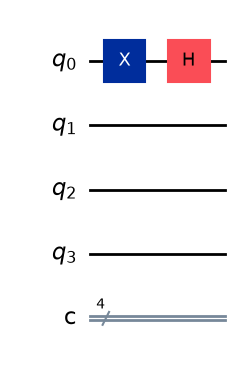

<br>**2. Vector de Estado (Notación Ket):**

<IPython.core.display.Latex object>

<br>**3. Visualización en la Esfera de Bloch:**

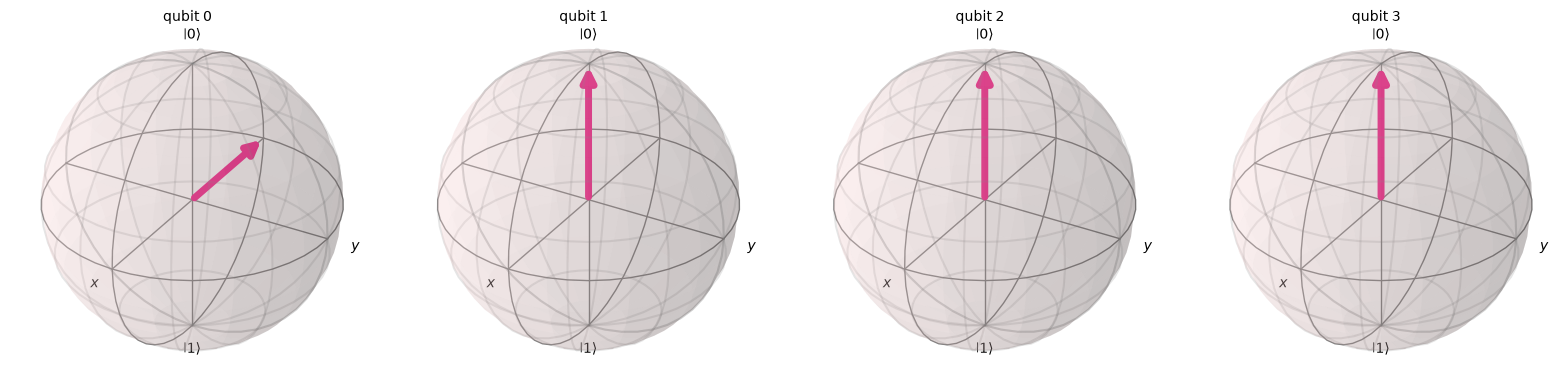

<br>**5. Probabilidades de Medición teóricas:**

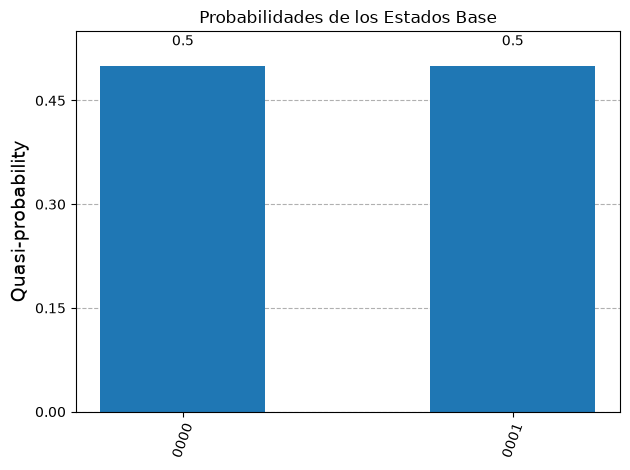

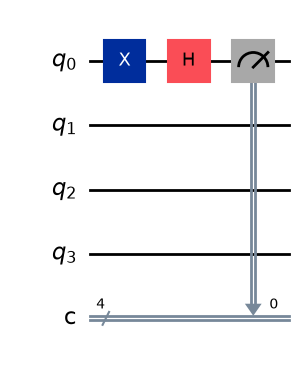

In [30]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
# aquí lo que hacemos es "crear 2 cajas" para guardar información
qreg_q = QuantumRegister(4,'q') # caja cuántica de 4 Qbits
creg_c = ClassicalRegister(4,'c') # caja clásica de 4 Bits
circuit = QuantumCircuit(qreg_q,creg_c) # aquí juntamos las 2 en mi circuito 
"""
y para qué sirve?
En los computadores cuánticos reales, necesitas cables cuánticos por donde viajan 
los estados en superposición, y cables clásicos (bits tradicionales de 0 y 1) para
guardar la información una vez que mides el circuito. Por defecto, todos los qubits
nacen en el estado fundamental |0>
"""
circuit.x(qreg_q[0])
circuit.h((qreg_q[0]))
analizar_circuito(circuit)
circuit.measure(qreg_q[0],creg_c[0])
display(circuit.draw('mpl'))



### Ejercicio 1
Implemente el siguiente estado: 
$$H|0\rangle$$

### Ejercicio 2
Implemente el siguiente estado: 
$$H|1\rangle$$

### Ejercicio 3
Implemente el siguiente estado: 
$$X|0\rangle$$

### Ejercicio 4
Implemente el siguiente estado: 
$$S|0\rangle$$

### Ejercicio 5
Implemente el siguiente estado: 
$$S^{\dagger}|0\rangle$$

### Ejercicio 6
Implemente el siguiente estado: 
$$S^{\dagger}|1\rangle$$

### Ejercicio 7
Implemente el siguiente estado secuencial: 
$$S\cdot H|0\rangle$$

### Ejercicio 8
Implemente el siguiente estado secuencial: 
$$H\cdot T\cdot H|0\rangle$$

## Circuitos

### Ejercicio 9
Implemente el siguiente producto tensorial: 
$$|0\rangle \otimes |0\rangle = |00\rangle$$

### Ejercicio 10
Implemente el siguiente producto tensorial: 
$$|1\rangle \otimes |1\rangle = |11\rangle$$

### Ejercicio 11
Implemente el siguiente producto tensorial: 
$$|1\rangle \otimes |0\rangle = |10\rangle$$

### Ejercicio 12
Implemente el siguiente producto tensorial: 
$$|0\rangle \otimes |1\rangle = |01\rangle$$

## Estados de Bell

### Ejercicio 13
Construya el circuito para: 
$$CNOT|00\rangle$$

### Ejercicio 14
Construya el circuito para: 
$$CNOT\cdot H|00\rangle$$

### Ejercicio 15
Construya el circuito para: 
$$CNOT\cdot H|10\rangle$$

### Ejercicio 16
Construya el circuito para: 
$$CNOT\cdot H|01\rangle$$

### Ejercicio 17
Construya el circuito para: 
$$CNOT\cdot H|11\rangle$$

### Ejercicio 18
Construya el circuito para: 
$$CNOT\cdot H\cdot Z|00\rangle$$


### Ejercicio 19
Construya el circuito de la figura 19 (Compuertas H, Z y CNOT).


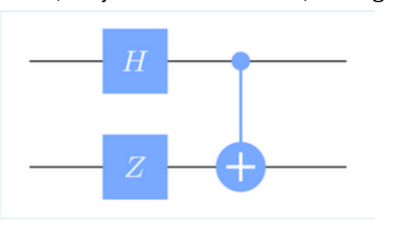

### Ejercicio 20
Construya el circuito de la figura 20 (Sistema con compuertas H, CNOT, Z).

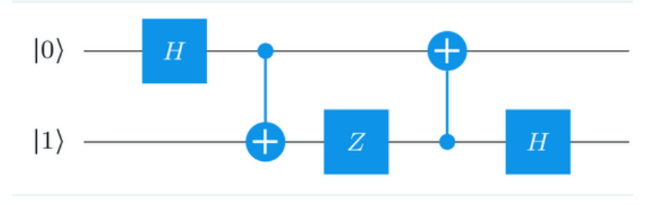

### Ejercicio 21
Construya el circuito de la figura 21 (Incluye compuertas X, H y S).


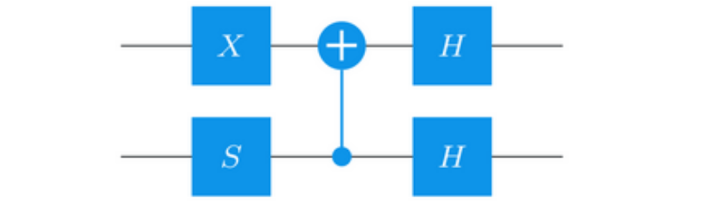

### Ejercicio 22
Implemente la compuerta: 
**Toffoli**

### Implemente el protocolo: 
**Alice y Bob**

In [31]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

# Protocolo de Teleportación Cuántica: Explicación Paso a Paso

El protocolo de teleportación permite la transmisión de un estado cuántico arbitrario utilizando dos bits de comunicación clásica, a costa de consumir un par de qubits entrelazados (conocido como *ebit*). 

A continuación, se detalla el procedimiento exacto que siguen los dos participantes, Alice (emisora) y Bob (receptor).

## Paso 1: Preparación del Estado Entrelazado
Antes de iniciar la transmisión del mensaje, el protocolo asume la existencia de un canal cuántico previo.
* Alice y Bob inicializan un par de qubits (A para Alice, B para Bob) compartiendo un estado entrelazado.
* Específicamente, este par se inicializa en el estado de Bell máximo $\vert \phi^+ \rangle$. 

## Paso 2: Operaciones Locales de Alice
Alice posee el qubit arbitrario (llamémosle Q) cuyo estado $\vert \psi \rangle$ desea teleportar a Bob. Para ello, debe hacer interactuar Q con su mitad del par entrelazado (A).
* **Entrelazamiento local:** Alice aplica una compuerta CNOT, utilizando el qubit Q como control y su qubit A como objetivo.
* **Cambio de base:** Seguidamente, Alice aplica una compuerta de Hadamard (H) sobre el qubit Q.

## Paso 3: Medición y Comunicación Clásica
Tras realizar sus compuertas locales, el estado global del sistema ha cambiado y la información se ha "distribuido".
* Alice realiza una medición en la base computacional sobre el qubit A para obtener un bit clásico $a$, y sobre el qubit Q para obtener un bit clásico $b$.
* Debido al colapso de la función de onda, el estado cuántico original en el laboratorio de Alice se destruye.
* Finalmente, Alice envía estos bits clásicos ($a$ y $b$) a Bob a través de un canal de comunicación tradicional.

## Paso 4: Operaciones Condicionales de Bob (Recuperación)
El qubit de Bob (B) contiene ahora la información del estado original, pero "codificada" según los resultados aleatorios de la medición de Alice. Bob utiliza los bits clásicos recibidos para aplicar compuertas de forma condicional y corregir el estado:
* Si el bit $a = 1$, Bob aplica una compuerta de inversión de bit (Pauli-X) a su qubit.
* Si el bit $b = 1$, Bob aplica una compuerta de inversión de fase (Pauli-Z) a su qubit.

Una vez aplicadas estas correcciones condicionales, el qubit de Bob es matemáticamente idéntico al estado inicial $\vert \psi \rangle$ que Alice poseía, completando así la teleportación.

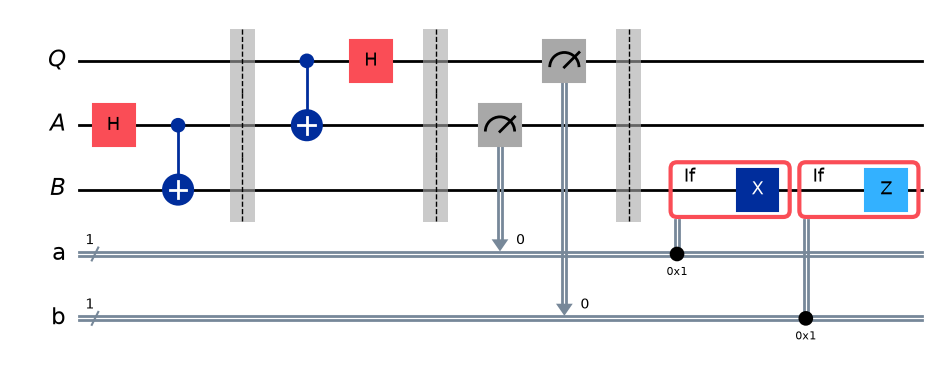

In [82]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)
# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()
# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()
# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)
display(protocol.draw(output="mpl"))

In [83]:
random_gate = UGate(
theta=random.random() * 2 * pi,
phi=random.random() * 2 * pi,
lam=random.random() * 2 * pi,
)
display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

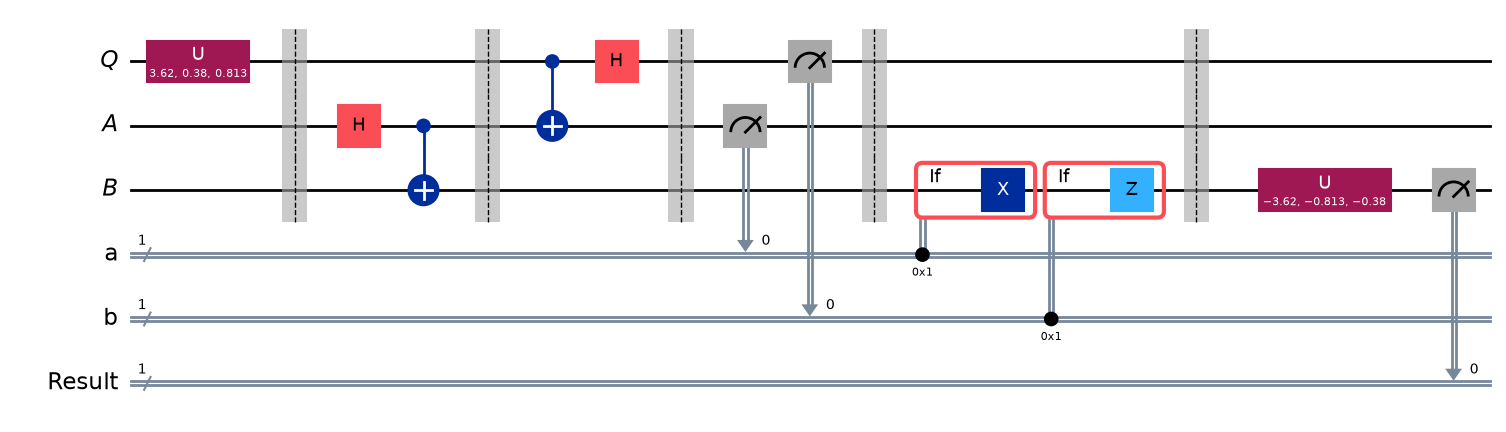

In [84]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)
# Start with the randomly selected gate on Q
test.append(random_gate, qubit)
test.barrier()
# Append the entire teleportation protocol from above.
test = test.compose(protocol)
test.barrier()
# Finally, apply the inverse of the random unitary to B and measure.
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)
display(test.draw(output="mpl"))

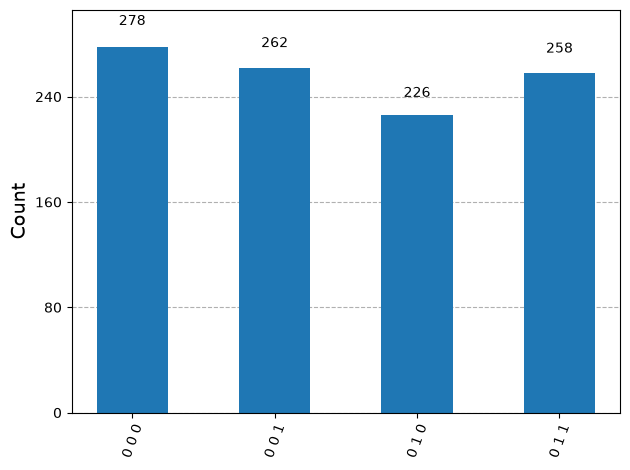

In [85]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

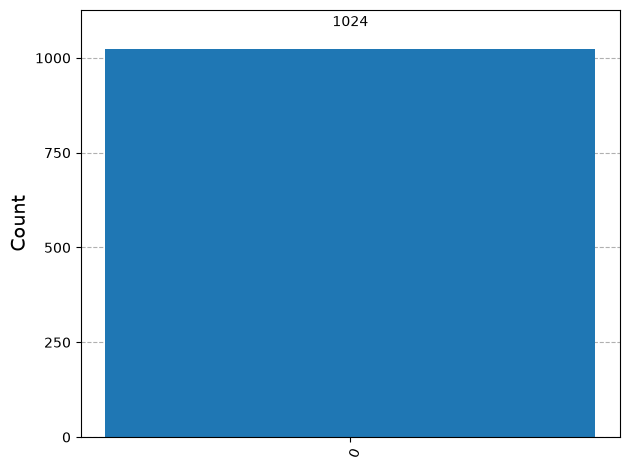

In [86]:

filtered_statistics = marginal_distribution(statistics,[2])
display(plot_histogram(filtered_statistics))

### Compilemos en un QC

In [87]:
from qiskit_ibm_runtime import QiskitRuntimeService
# Pasamos únicamente el string del apikey
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="", 
    overwrite=True
)

# Iniciamos el servicio (ya recuerda tu clave)
service = QiskitRuntimeService()


InvalidAccountError: "Invalid `token` value. Expected a non-empty string, got ''."

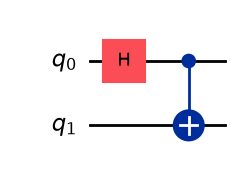

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")


In [ ]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

In [ ]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

IBMInputValueError: 'No matching instances found for the following filters: .'

In [ ]:

# Use the following code instead if you want to run on a simulator:

from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)

# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()

# This is the result of the entire submission. You submitted one Pub,
# so this contains one inner result (and some metadata of its own).

job_result = job.result()

# This is the result from our single pub, which had five observables,
# so contains information on all five.

pub_result = job.result()[0]


In [ ]:
# Construct the Estimator instance.

estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: f52321ea-0a73-468f-9714-33cfbd5bd6cf


/home/troncos1/Documentos/códigos/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")


In [ ]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

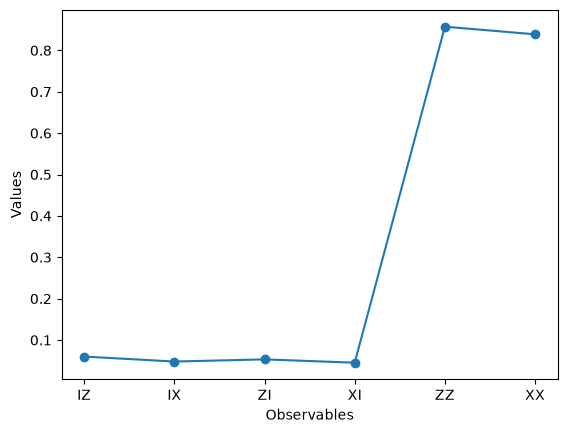

In [ ]:
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

In [ ]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc)
        for an n-qubit GHZ state.

    Args:
        n (int): Number of qubits in the n-qubit GHZ state

    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state,
            assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc


# Create a new circuit with 100 qubits in the GHZ state
n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)

In [ ]:
# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = [
    "Z" + "I" * i + "Z" + "I" * (n - 2 - i) for i in range(n - 1)
]

operators = [SparsePauliOp(operator) for operator in operator_strings]

In [ ]:
service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

isa_circuit = pm.run(qc)
isa_operators_list = [op.apply_layout(isa_circuit.layout) for op in operators]

IBMInputValueError: 'No matching instances found for the following filters: .'

In [ ]:
options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

# Create an Estimator object
estimator = Estimator(backend, options=options)

In [ ]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()
print(job_id)

NameError: name 'isa_operators_list' is not defined

ValueError: x and y must have same first dimension, but have shapes (99,) and (6,)

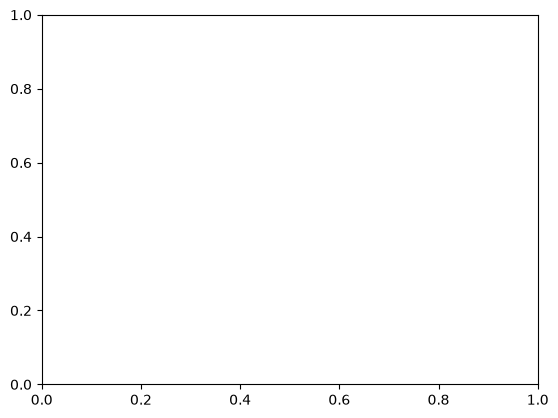

In [ ]:
# data
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.

# plotting graph
plt.plot(data, values, marker="o", label="100-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()

# ALice y Bob en un QC

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Conectar al servicio
service = QiskitRuntimeService()

# Seleccionar el procesador real menos ocupado
backend = service.least_busy(operational=True, simulator=False)
print(f"Hardware cuántico seleccionado: {backend.name}")

IBMInputValueError: 'No matching instances found for the following filters: .'

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(3, name="q")
cr = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qr, cr)

# 1. Estado inicial de Alice a transferir (ejemplo: |1>)
qc.x(qr[0])

# 2. Entrelazamiento del canal cuántico (Par de Bell entre Alice q1 y Bob q2)
qc.h(qr[1])
qc.cx(qr[1], qr[2])

# 3. Operaciones de Alice
qc.cx(qr[0], qr[1])
qc.h(qr[0])

# 4. Alice mide sus dos qubits
qc.measure(qr[0], cr[0])
qc.measure(qr[1], cr[1])

# 5. Bob aplica correcciones según las mediciones clásicas (Dynamic Circuit)
with qc.if_test((cr[1], 1)):
    qc.x(qr[2])
with qc.if_test((cr[0], 1)):
    qc.z(qr[2])

# 6. Medición final del estado recibido por Bob
qc.measure(qr[2], cr[2])

In [ ]:
# Transpilar a la arquitectura ISA del procesador
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Ejecutar el trabajo en el hardware real con SamplerV2
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1024)

print(f"Trabajo enviado exitosamente. Job ID: {job.job_id()}")

TranspilerError: "The control-flow construct 'if_else' is not supported by the backend."

In [ ]:
# Esperar resultado del backend físico
result = job.result()
pub_result = result[0]

# Obtener conteos de los bits medidos
counts = pub_result.data.c.get_counts()

# Graficar histograma
plot_histogram(counts)
plt.title(f"Resultados de Teletransportación en {backend.name}")
plt.show()